# K-Nearest Neighbors (KNN) on Fashion-MNIST

## Objective

Implement the K-Nearest Neighbors (KNN) algorithm for image classification using the Fashion-MNIST dataset and study the effect of different K values on accuracy and computational efficiency.

## Tasks

- Load and preprocess the Fashion-MNIST dataset.
- Implement KNN for multi-class classification.
- Experiment with different values of K.
- Evaluate accuracy and prediction time.
- Analyze how K affects model performance and computational efficiency.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

Load Fashion-MNIST

In [3]:
# Load Fashion-MNIST dataset

(X_train_full, y_train_full), (X_test_full, y_test_full) = fashion_mnist.load_data()

print("Training data shape:", X_train_full.shape)
print("Testing data shape :", X_test_full.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape : (10000, 28, 28)


In [2]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

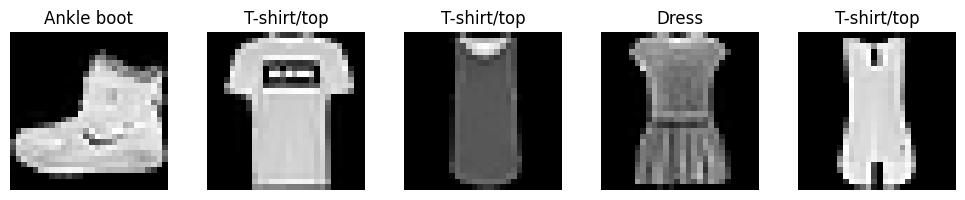

In [4]:
# Display first 5 training images

plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Normalize the Data

In [5]:
# Convert pixel values from 0-255 to 0-1

X_train_full = X_train_full.astype("float32") / 255.0
X_test_full = X_test_full.astype("float32") / 255.0

print("Minimum pixel value:", X_train_full.min())
print("Maximum pixel value:", X_train_full.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


Flatten Images

In [6]:
# Convert 28 x 28 images into 784-dimensional vectors

X_train_full = X_train_full.reshape(len(X_train_full), -1)
X_test_full = X_test_full.reshape(len(X_test_full), -1)

print("Training shape:", X_train_full.shape)
print("Testing shape :", X_test_full.shape)

Training shape: (60000, 784)
Testing shape : (10000, 784)


Create Smaller Dataset

In [7]:
# Use a smaller dataset for faster KNN execution

X_train, _, y_train, _ = train_test_split(
    X_train_full,
    y_train_full,
    train_size=12000,
    stratify=y_train_full,
    random_state=42
)

X_test, _, y_test, _ = train_test_split(
    X_test_full,
    y_test_full,
    train_size=2000,
    stratify=y_test_full,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (12000, 784)
Testing data : (2000, 784)


Create KNN Model

In [8]:
# Create KNN model

knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


Make Predictions

In [9]:
# Start timer
start = time.perf_counter()

# Predict test data
y_pred = knn.predict(X_test)

# Calculate prediction time
prediction_time = time.perf_counter() - start

print("Prediction time:", prediction_time, "seconds")

Prediction time: 1.6963408130000062 seconds


Calculate Accuracy

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("K =", 5)
print("Accuracy =", accuracy * 100, "%")

K = 5
Accuracy = 81.8 %


Experiment With Different K Values

In [12]:
k_values = [1, 3, 5, 7, 9]

results = []

for k in k_values:

    # Create KNN model
    knn = KNeighborsClassifier(
        n_neighbors=k,
        n_jobs=-1
    )

    # Train
    knn.fit(X_train, y_train)

    # Start timer
    start = time.perf_counter()

    # Predict
    y_pred = knn.predict(X_test)

    # Calculate prediction time
    prediction_time = time.perf_counter() - start

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Store results
    results.append({
        "K": k,
        "Accuracy": accuracy,
        "Prediction Time": prediction_time
    })

    print(
        f"K = {k}, "
        f"Accuracy = {accuracy:.4f}, "
        f"Time = {prediction_time:.2f} seconds"
    )

K = 1, Accuracy = 0.8090, Time = 1.17 seconds
K = 3, Accuracy = 0.8240, Time = 1.25 seconds
K = 5, Accuracy = 0.8180, Time = 1.37 seconds
K = 7, Accuracy = 0.8220, Time = 1.18 seconds
K = 9, Accuracy = 0.8195, Time = 1.02 seconds


In [13]:
results_df = pd.DataFrame(results)

print(results_df)

   K  Accuracy  Prediction Time
0  1    0.8090         1.169697
1  3    0.8240         1.246666
2  5    0.8180         1.368446
3  7    0.8220         1.184559
4  9    0.8195         1.021492


K vs Accuracy

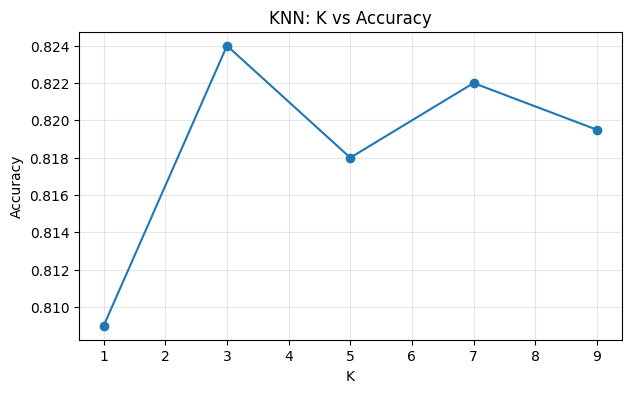

In [14]:
plt.figure(figsize=(7, 4))

plt.plot(
    results_df["K"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN: K vs Accuracy")

plt.grid(alpha=0.3)
plt.show()

Plot K vs Prediction Time

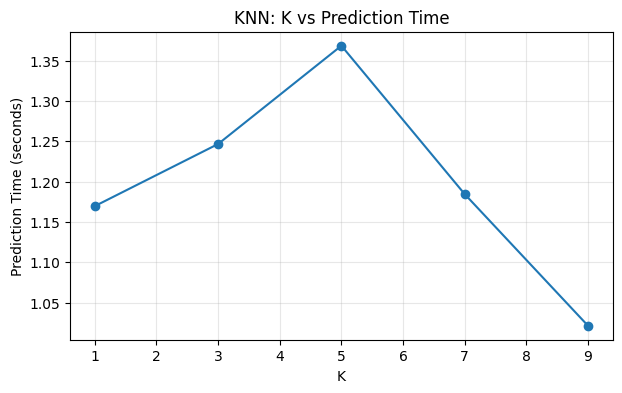

In [15]:
plt.figure(figsize=(7, 4))

plt.plot(
    results_df["K"],
    results_df["Prediction Time"],
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Prediction Time (seconds)")
plt.title("KNN: K vs Prediction Time")

plt.grid(alpha=0.3)
plt.show()

Findinh Besy K

In [16]:
# Find K with the highest accuracy

best_index = results_df["Accuracy"].idxmax()

best_k = results_df.loc[best_index, "K"]
best_accuracy = results_df.loc[best_index, "Accuracy"]

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 3
Best Accuracy: 0.824


Final Model With Best K

In [17]:
# Create final KNN model using best K

best_model = KNeighborsClassifier(
    n_neighbors=int(best_k),
    n_jobs=-1
)

best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_test)

print("Final model trained with K =", best_k)

Final model trained with K = 3


Confusion Matrix

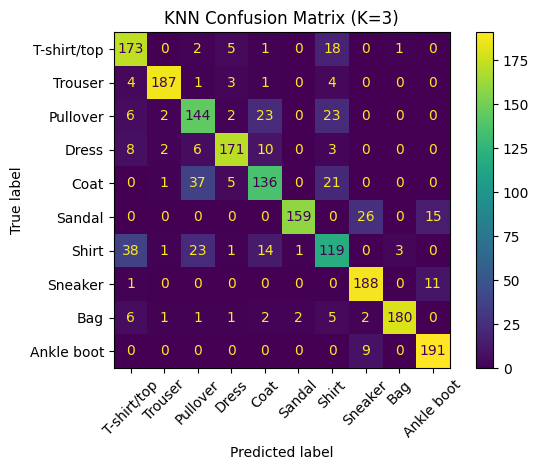

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=class_names,
    xticks_rotation=45
)

plt.title(f"KNN Confusion Matrix (K={best_k})")
plt.tight_layout()
plt.show()

## Observation

KNN was implemented on the Fashion-MNIST dataset for multi-class
classification. Different values of K (1, 3, 5, 7 and 9) were tested.

The accuracy and prediction time were recorded for each K value.
A small K such as K=1 can be sensitive to noise, while a very large K
can over-smooth the decision boundary. The best K was selected based
on the highest test accuracy.

KNN has relatively low training cost but prediction can be
computationally expensive because distances to many training samples
must be calculated.